=== VERSION 1: SGD with Sigmoid (No Normalization) ===
Loading MNIST data...


C:\Users\User\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Training data shape: (60000, 784)
Test data shape: (10000, 784)

Training with Sigmoid activation (No Normalization)...
Epoch 1/5:
  Loss: 1.1223, Accuracy: 0.7286
Epoch 2/5:
  Loss: 0.4410, Accuracy: 0.8839
Epoch 3/5:
  Loss: 0.3573, Accuracy: 0.8998
Epoch 4/5:
  Loss: 0.3227, Accuracy: 0.9078
Epoch 5/5:
  Loss: 0.3016, Accuracy: 0.9125


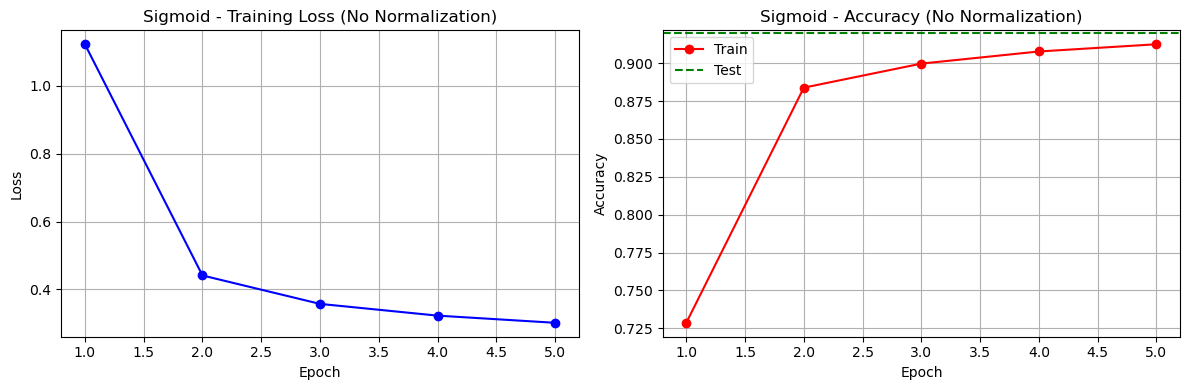


=== RESULTS: Sigmoid (No Normalization) ===
Epoch 1: Loss = 1.1223, Train Acc = 0.7286
Epoch 2: Loss = 0.4410, Train Acc = 0.8839
Epoch 3: Loss = 0.3573, Train Acc = 0.8998
Epoch 4: Loss = 0.3227, Train Acc = 0.9078
Epoch 5: Loss = 0.3016, Train Acc = 0.9125
Final Test Accuracy: 0.9199


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("=== VERSION 1: SGD with Sigmoid (No Normalization) ===")

# Load MNIST data
print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Split into train and test (standard MNIST split)
X_train = X[:60000] / 255.0  # Scale to [0,1] but no normalization
X_test = X[60000:] / 255.0
y_train = y[:60000]
y_test = y[60000:]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Convert labels to one-hot encoding
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# Network parameters
d = 784  # input dimension
h = 128  # hidden units
k = 10   # output classes

# Initialize weights (Xavier initialization for sigmoid)
W1 = np.random.uniform(-1/np.sqrt(d), 1/np.sqrt(d), (h, d))
W2 = np.random.uniform(-1/np.sqrt(h), 1/np.sqrt(h), (k, h))

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# Training parameters
learning_rate = 1e-3
batch_size = 1
epochs = 5

# Storage for metrics
train_losses = []
train_accuracies = []

print("\nTraining with Sigmoid activation (No Normalization)...")
for epoch in range(epochs):
    epoch_loss = 0
    epoch_correct = 0
    num_batches = 0
    
    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_epoch = X_train[indices]
    y_epoch = y_train_onehot[indices]
    y_labels_epoch = y_train[indices]
    
    for i in range(0, len(X_epoch), batch_size):
        x = X_epoch[i].reshape(-1, 1)
        y = y_epoch[i].reshape(-1, 1)
        y_label = y_labels_epoch[i]
        
        # Forward pass
        a1 = W1 @ x
        h1 = sigmoid(a1)
        a2 = W2 @ h1
        y_hat = softmax(a2)
        
        # Compute loss and accuracy
        loss = -np.sum(y * np.log(y_hat + 1e-8))
        epoch_loss += loss
        predicted_class = np.argmax(y_hat)
        if predicted_class == y_label:
            epoch_correct += 1
        
        # Backward pass
        delta2 = y_hat - y
        dW2 = delta2 @ h1.T
        
        delta_h = W2.T @ delta2
        sig_deriv = sigmoid_derivative(h1)
        delta1 = delta_h * sig_deriv
        dW1 = delta1 @ x.T
        
        # Update weights
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1
        
        num_batches += 1
    
    # Epoch statistics
    avg_loss = epoch_loss / num_batches
    accuracy = epoch_correct / num_batches
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Test accuracy
test_correct = 0
for i in range(len(X_test)):
    x = X_test[i].reshape(-1, 1)
    y_label = y_test[i]
    
    a1 = W1 @ x
    h1 = sigmoid(a1)
    a2 = W2 @ h1
    y_hat = softmax(a2)
    
    predicted_class = np.argmax(y_hat)
    if predicted_class == y_label:
        test_correct += 1

test_accuracy = test_correct / len(X_test)

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, 'b-o')
plt.title('Sigmoid - Training Loss (No Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, 'r-o', label='Train')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test')
plt.title('Sigmoid - Accuracy (No Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== RESULTS: Sigmoid (No Normalization) ===")
for epoch in range(epochs):
    print(f"Epoch {epoch+1}: Loss = {train_losses[epoch]:.4f}, Train Acc = {train_accuracies[epoch]:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")